# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

Dataset yang digunakan pada eksperimen ini adalah **Iris Dataset**, salah satu dataset paling populer dalam dunia machine learning. Dataset ini pertama kali diperkenalkan oleh Ronald Fisher pada tahun 1936. Iris dataset berisi 150 sampel dari tiga spesies bunga iris (*Iris setosa*, *Iris versicolor*, dan *Iris virginica*) dengan empat fitur pengukuran:
- **sepal_length**: Panjang sepal (cm)
- **sepal_width**: Lebar sepal (cm)
- **petal_length**: Panjang petal (cm)
- **petal_width**: Lebar petal (cm)
- **species**: Label kelas (setosa, versicolor, virginica)

**Tujuan**: Membangun model klasifikasi untuk memprediksi spesies bunga iris berdasarkan dimensi sepal dan petal.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimpor')

Library berhasil diimpor


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv('../iris_raw.csv')

print('Shape dataset:', df.shape)
print('\n5 data pertama:')
df.head()

Shape dataset: (150, 5)

5 data pertama:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
print('5 data terakhir:')
df.tail()

5 data terakhir:


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [4]:
print('Informasi dataset:')
df.info()

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
print('Statistik deskriptif:')
df.describe()

Statistik deskriptif:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [6]:
print('Jumlah nilai kosong per kolom:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

Jumlah nilai kosong per kolom:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Total missing values: 0


In [7]:
print('Jumlah data duplikat:', df.duplicated().sum())

Jumlah data duplikat: 1


Distribusi kelas (species):
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


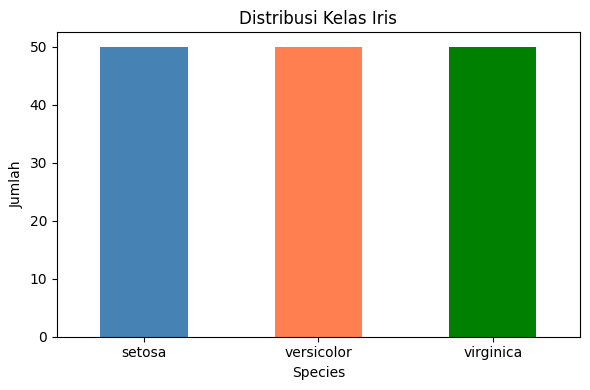

In [8]:
print('Distribusi kelas (species):')
print(df['species'].value_counts())

plt.figure(figsize=(6, 4))
df['species'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'green'])
plt.title('Distribusi Kelas Iris')
plt.xlabel('Species')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

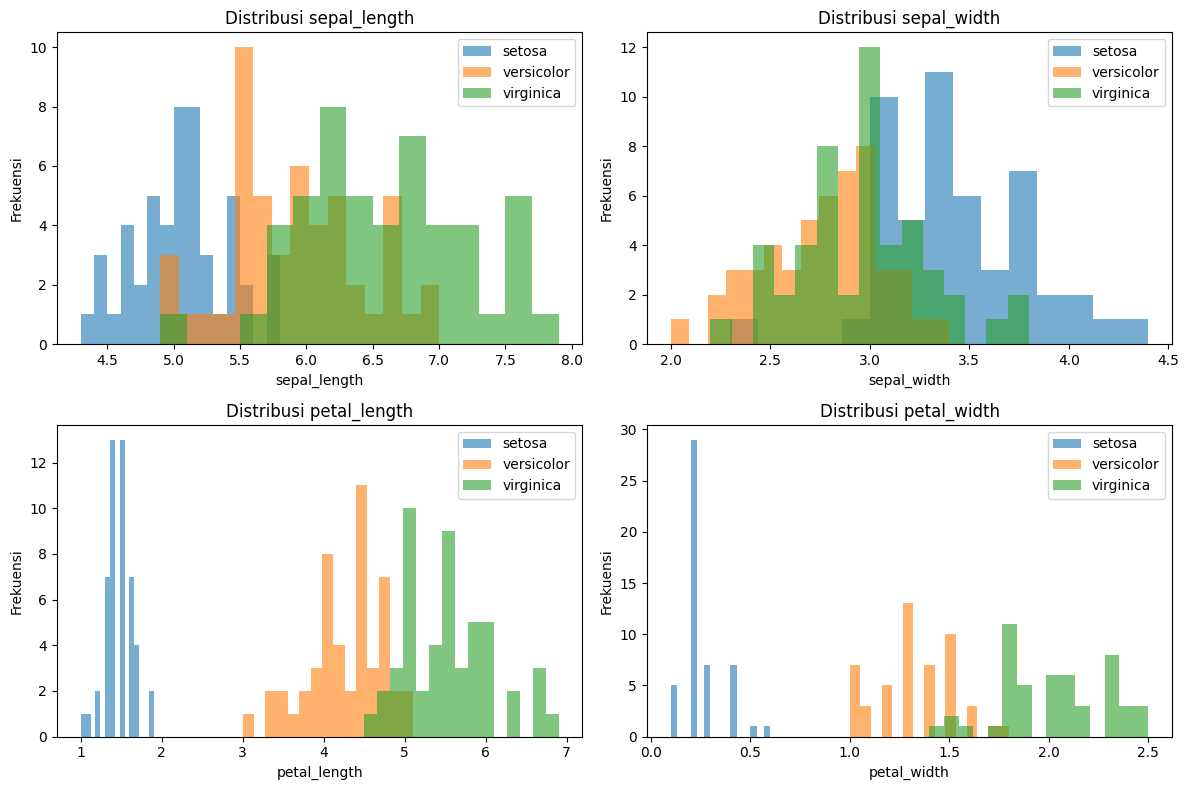

In [9]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 2][i % 2]
    for species in df['species'].unique():
        ax.hist(df[df['species'] == species][col], alpha=0.6, label=species, bins=15)
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.legend()
plt.tight_layout()
plt.show()

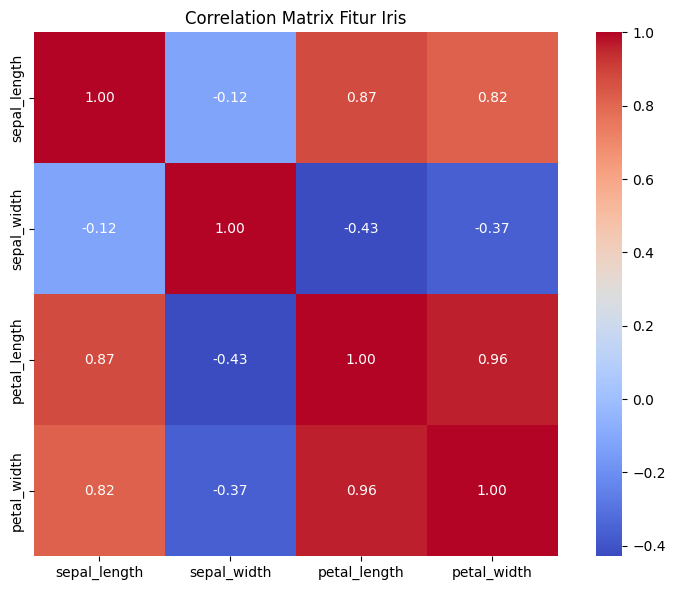

In [10]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[feature_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix Fitur Iris')
plt.tight_layout()
plt.show()

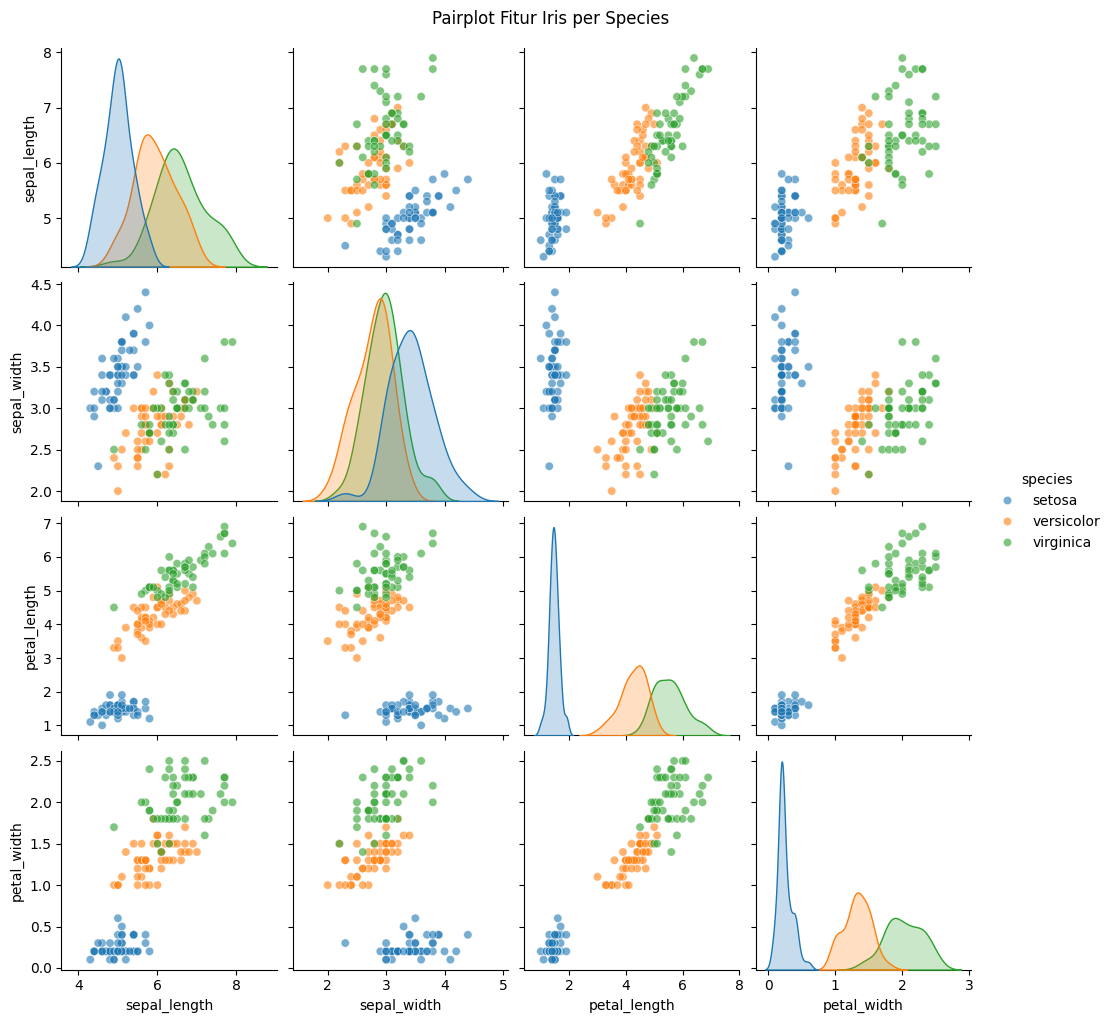

In [11]:
sns.pairplot(df, hue='species', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot Fitur Iris per Species', y=1.02)
plt.show()

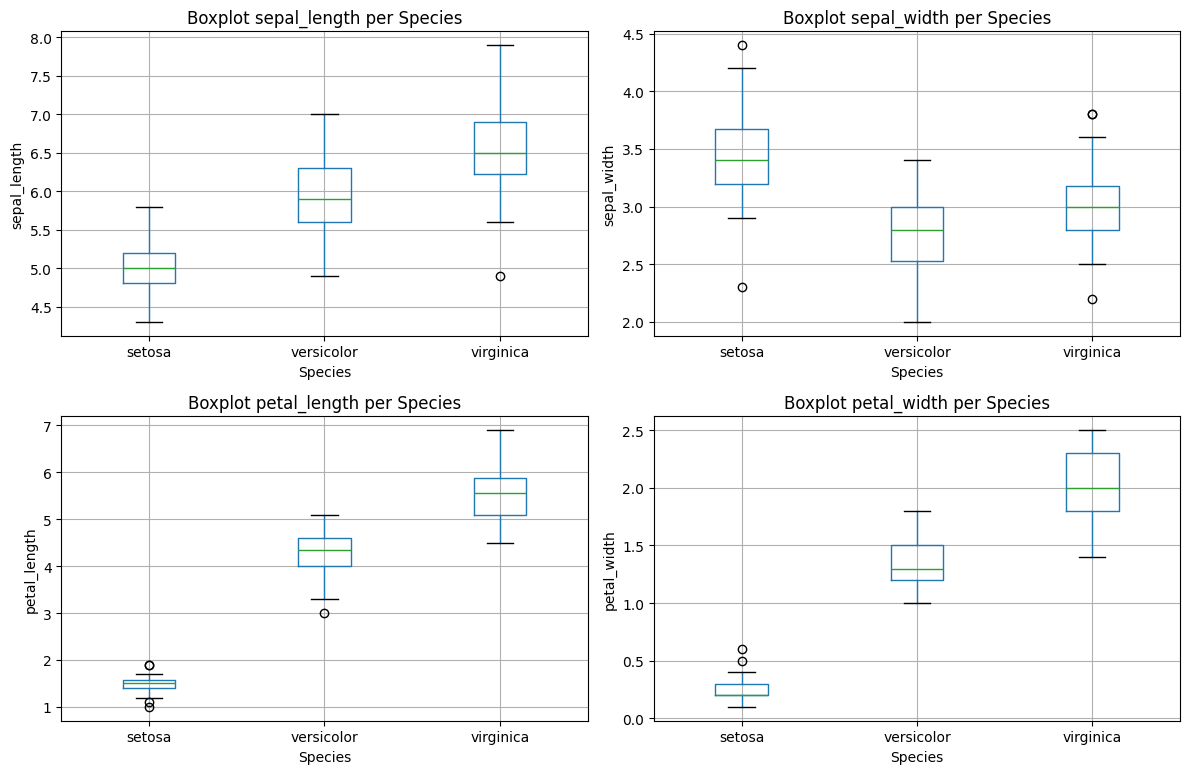

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(feature_cols):
    ax = axes[i // 2][i % 2]
    df.boxplot(column=col, by='species', ax=ax)
    ax.set_title(f'Boxplot {col} per Species')
    ax.set_xlabel('Species')
    ax.set_ylabel(col)
plt.suptitle('')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
df_processed = df.copy()
print('Shape sebelum preprocessing:', df_processed.shape)

Shape sebelum preprocessing: (150, 5)


In [14]:
df_processed = df_processed.dropna()
print('Shape setelah menghapus missing values:', df_processed.shape)

Shape setelah menghapus missing values: (150, 5)


In [15]:
df_processed = df_processed.drop_duplicates()
print('Shape setelah menghapus duplikat:', df_processed.shape)

Shape setelah menghapus duplikat: (149, 5)


In [16]:
Q1 = df_processed[feature_cols].quantile(0.25)
Q3 = df_processed[feature_cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df_processed[feature_cols] < (Q1 - 1.5 * IQR)) |
         (df_processed[feature_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df_processed = df_processed[mask]
print('Shape setelah menghapus outlier:', df_processed.shape)

Shape setelah menghapus outlier: (145, 5)


In [17]:
le = LabelEncoder()
df_processed['species'] = le.fit_transform(df_processed['species'])

print('Mapping label encoding:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} -> {i}')

Mapping label encoding:
  setosa -> 0
  versicolor -> 1
  virginica -> 2


In [18]:
scaler = StandardScaler()
df_processed[feature_cols] = scaler.fit_transform(df_processed[feature_cols])

print('Statistik setelah standarisasi:')
df_processed[feature_cols].describe().round(4)

Statistik setelah standarisasi:


,sepal_length,sepal_width,petal_length,petal_width
count,145.0000,145.0000,145.0000,145.0000
mean,0.0000,-0.0000,-0.0000,-0.0000
std,1.0035,1.0035,1.0035,1.0035
min,-1.8670,-2.1237,-1.5945,-1.4735
25%,-0.9079,-0.6117,-1.2526,-1.2094
50%,-0.0686,-0.1077,0.3431,0.1111
75%,0.6507,0.6482,0.7420,0.7714
max,2.4491,2.4122,1.7678,1.6957


In [19]:
print('5 data pertama setelah preprocessing:')
df_processed.head()

5 data pertama setelah preprocessing:


,sepal_length,sepal_width,petal_length,petal_width,species
0,-0.907877,1.152206,-1.366548,-1.341462,0
1,-1.147662,-0.107748,-1.366548,-1.341462,0
2,-1.387447,0.396234,-1.423536,-1.341462,0
3,-1.507340,0.144243,-1.309559,-1.341462,0
4,-1.027769,1.404196,-1.366548,-1.341462,0


In [20]:
import os
os.makedirs('iris_preprocessing', exist_ok=True)
df_processed.to_csv('iris_preprocessing/iris_preprocessing.csv', index=False)
print('Data preprocessing berhasil disimpan ke iris_preprocessing/iris_preprocessing.csv')
print('Shape akhir:', df_processed.shape)

Data preprocessing berhasil disimpan ke iris_preprocessing/iris_preprocessing.csv
Shape akhir: (145, 5)
